In [1]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

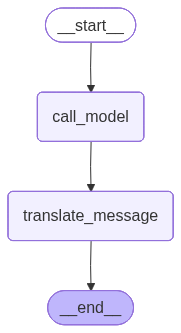

In [2]:
from typing import TypedDict, Annotated
from langchain.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from IPython.display import display,Image
from langgraph.checkpoint.memory import MemorySaver


class State(TypedDict):
    messages:Annotated[list,add_messages]
    
    
def call_model(state:State):
    response=llm.invoke(state["messages"])
    return {"messages":response}

def translate_message(state:State):
    system_prompt="""
    Please translate the text in any language into English as output
    """
    messages=state["messages"][-1]
    messages=[SystemMessage(content=system_prompt)]+ [HumanMessage(content=messages.content)]
    response=llm.invoke(messages)
    return {"messages":response}

builder=StateGraph(State)

builder.add_node("call_model",call_model)
builder.add_node("translate_message",translate_message)

builder.add_edge(START,"call_model")
builder.add_edge("call_model","translate_message")
builder.add_edge("translate_message",END)

memory=MemorySaver()
graph_with_memory=builder.compile(checkpointer=memory)

display(Image(graph_with_memory.get_graph(xray=True).draw_mermaid_png()))
    

In [4]:
config={"configurable":{"thread_id":"1"}}
async for chunk in graph_with_memory.astream(input={"messages":["你好，我叫西瓜老师"]},config=config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()
    


================================ Human Message =================================

你好，我叫西瓜老师
================================== Ai Message ==================================

你好，西瓜老师！🍉 很高兴认识你！有什么我可以帮你的吗？无论是学习、工作还是生活中的问题，都可以随时问我哦～ 😊
================================== Ai Message ==================================

Hello, Teacher Watermelon! 🍉 Nice to meet you! Is there anything I can help you with? Whether it's about studying, work, or daily life, feel free to ask me anytime~ 😊


In [5]:
for chunk in graph_with_memory.stream({"messages":["你好，我叫西瓜老师"]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我叫西瓜老师
================================== Ai Message ==================================

哈哈，西瓜老师你好呀！🍉 看来你很喜欢这个可爱的名字～ 再次认识你也很开心！有什么需要我帮忙的吗？无论是知识问题、创意脑洞，还是想聊聊有趣的话题，我都在这儿等着你哦～ 😄
================================== Ai Message ==================================

Haha, hello Watermelon Teacher! 🍉 It seems you really like this cute name～ Nice to meet you again! Is there anything I can help you with? Whether it's knowledge questions, creative ideas, or just chatting about fun topics, I'm right here waiting for you～ 😄


In [6]:
for chunk in graph_with_memory.stream({"messages":["请问我叫什么"]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

请问我叫什么
================================== Ai Message ==================================

哈哈，西瓜老师，你当然叫 **西瓜老师** 呀！🍉  
不过如果你愿意告诉我你的真实名字或昵称，我也可以记住并这样称呼你哦～ 😊  

（悄悄说：就算你叫“哈密瓜老师”或“小草莓同学”，我也能一秒切换模式！✨）
================================== Ai Message ==================================

Haha, Watermelon Teacher, of course you're called **Watermelon Teacher**! 🍉  
But if you're willing to tell me your real name or nickname, I can remember and call you that too~ 😊  

(Whispering: Even if you're called "Cantaloupe Teacher" or "Little Strawberry Classmate," I can switch modes in a second! ✨)


In [ ]:
for chunk in graph_with_memory.stream({"messages":["我刚才都问了你什么问题？"]},config,stream_mode="debug"):
    print(chunk)

In [15]:
config2={"configurable":{"thread_id":"2"}}
for chunk in graph_with_memory.stream({"messages":["我刚才都问了你什么问题？"]},config2,stream_mode="debug"):
    if chunk['type']=='checkpoint':
        print(f'Thread id:{chunk["payload"]["config"]["configurable"]["thread_id"]}')
        print(f'Checkpoint id :{chunk["payload"]["config"]["configurable"]["checkpoint_id"]}')
        for message in chunk['payload']['values']['messages']:
            print(f"Message id:{message.id}, Message content:{message.content}")

Thread id:2
Checkpoint id :1f16c723-c039-66a6-8004-3b15b4c59cf6
Message id:7b1b8566-1345-4f7d-be89-f6dceb90a8b9, Message content:我刚才都问了你什么问题？
Message id:lc_run--019ee3bd-8195-7292-9e48-2b4198a4872c-0, Message content:你刚才问的是：“我刚才都问了你什么问题？” 这是一个关于对话历史回顾的问题。不过，由于我们的对话刚刚开始，这是你发送的第一条消息，所以在此之前你并没有问过其他问题哦～ 如果你需要回顾之前的对话内容，可以告诉我具体想了解哪部分，我会尽力帮你整理！ 😊
Message id:lc_run--019ee3bd-8711-71b2-a469-4a6d3337c3d1-0, Message content:You just asked: "What questions did I ask you earlier?" This is a question about reviewing the conversation history. However, since our conversation has just begun and this is the first message you've sent, you haven't asked any other questions before this~ If you need to review previous conversation content, feel free to let me know which part you'd like to know about, and I'll do my best to help organize it for you! 😊
Thread id:2
Checkpoint id :1f16c723-c03c-6213-8005-ebd13b15b124
Message id:7b1b8566-1345-4f7d-be89-f6dceb90a8b9, Message content:我刚才都问了你什么问题？
Message id:lc_run